In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, mean_squared_error,
                             mean_absolute_error, r2_score)
from sklearn.linear_model import LogisticRegression, SGDClassifier, SGDRegressor, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from imblearn.over_sampling import SMOTE, SVMSMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.under_sampling import TomekLinks, RandomUnderSampler, NearMiss, EditedNearestNeighbours
from sklearn.base import clone
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, auc
import flaml
import xgboost as xgb
print(f'FLAML version: {flaml.__version__}')
import pickle
import shap
import json

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

FLAML version: 2.5.0


In [7]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

# print("Path to dataset files:", path)

# src

In [8]:
def inspect_dataset(dataset, dataset_name):
    print(f"Inspecting dataset: {dataset_name}")
    print("Dataset shape:", dataset.shape)
    print("Dataset columns:", dataset.columns)
    print("Dataset head:")
    display(dataset.head())

In [9]:
def calculate_statistical_summary(df, columns):
    # Shape and dtypes
    print(f"Shape: {df[columns].shape}\n")
    print("Column dtypes:")
    print(df[columns].dtypes.to_string())
    print(f"\n--- Missing Values ---")
    missing = df[columns].isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
    display(missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False))

In [10]:
def get_missing_rows(df, n=5, mode='top'):
    # Calculate missing percentage per row
    percent_missing = (df.isnull().sum(axis=1) / len(df.columns)) * 100
    
    result = df.copy()
    result['missing_pct'] = percent_missing
    # Sort descending so 'top' is always the most missing
    result = result.sort_values(by='missing_pct', ascending=False)
    
    if mode == 'top':
        return result.head(n)
    
    elif mode == 'bottom':
        return result.tail(n)
    
    elif mode == 'middle':
        mid = len(result) // 2
        return result.iloc[mid - n//2 : mid + (n - n//2)]
    
    return result

# Data Ingestion

In [11]:
DATA_PATH = "./data/"
orders = pd.read_csv(DATA_PATH + "olist_orders_dataset.csv")
customers = pd.read_csv(DATA_PATH + "olist_customers_dataset.csv")
order_items = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_PATH + "olist_sellers_dataset.csv")
payments = pd.read_csv(DATA_PATH + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_PATH + "olist_order_reviews_dataset.csv")
category = pd.read_csv(DATA_PATH + "product_category_name_translation.csv")

all_csv = {    
    "orders": orders,
    "customers": customers,
    "order_items": order_items,
    "products": products,
    "sellers": sellers,
    "payments": payments,
    "reviews": reviews,
    "category": category
}

In [12]:
for csv in all_csv:
    inspect_dataset(all_csv[csv], csv)

Inspecting dataset: orders
Dataset shape: (99441, 8)
Dataset columns: Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')
Dataset head:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Inspecting dataset: customers
Dataset shape: (99441, 5)
Dataset columns: Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
Dataset head:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Inspecting dataset: order_items
Dataset shape: (112650, 7)
Dataset columns: Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
Dataset head:


...

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


Inspecting dataset: reviews
Dataset shape: (99224, 7)
Dataset columns: Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')
Dataset head:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


Inspecting dataset: category
Dataset shape: (71, 2)
Dataset columns: Index(['product_category_name', 'product_category_name_english'], dtype='object')
Dataset head:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


## Merging onto a single dataset

In [13]:
products_en = products.merge(category, on="product_category_name", how="left")

In [14]:
# some orders have multiple payment rows
payments_agg = payments.groupby("order_id").agg(
    payment_type=("payment_type", "first"),
    payment_installments=("payment_installments", "sum"),
    payment_value=("payment_value", "sum")
).reset_index()

In [15]:
df = orders.merge(customers, on="customer_id", how="left")
df = df.merge(order_items, on="order_id", how="left")
df = df.merge(products_en, on="product_id", how="left")
df = df.merge(sellers, on="seller_id", how="left")
df = df.merge(payments_agg, on="order_id", how="left")
df = df.merge(reviews[["order_id", "review_score"]], on="order_id", how="left")

date_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date",'shipping_limit_date'
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

print(f"Merged table shape: {df.shape}")
df.head(3)

Merged table shape: (114092, 34)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_type,payment_installments,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP,credit_card,3.0,38.71,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,31570.0,belo horizonte,SP,boleto,1.0,141.46,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,14840.0,guariba,SP,credit_card,3.0,179.12,5.0


In [16]:
remove_columns = ["customer_zip_code_prefix","seller_zip_code_prefix"]
df.drop(columns=remove_columns, inplace=True)

In [17]:
df.product_category_name_english.value_counts()

product_category_name_english
bed_bath_table                             11270
health_beauty                               9727
sports_leisure                              8700
furniture_decor                             8415
computers_accessories                       7894
housewares                                  6989
watches_gifts                               6001
telephony                                   4550
garden_tools                                4361
auto                                        4256
toys                                        4125
cool_stuff                                  3806
perfumery                                   3435
baby                                        3073
electronics                                 2768
stationery                                  2525
fashion_bags_accessories                    2050
pet_shop                                    1949
office_furniture                            1701
consoles_games                         

### Feature Engineer the Date Columns right now to get meaning out of it

In [18]:
date_cols

['order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'shipping_limit_date']

In [19]:
df['approval_lag_hrs'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / 3600

In [20]:
df['seller_prep_days'] = (df['order_delivered_carrier_date'] - df['order_approved_at']).dt.days


In [21]:
df['seller_shipping_violation']  =  (df['order_delivered_carrier_date'] - df['shipping_limit_date']).dt.days

In [22]:
df['estimated_window_days']      = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days
df['buffer_days']                = (df['order_estimated_delivery_date'] - df['order_delivered_carrier_date']).dt.days
df['early_delivery_days']        = (df['order_estimated_delivery_date'] - df['order_delivered_customer_date']).dt.days

In [23]:
engineered_date_cols = [
    'approval_lag_hrs', 'seller_prep_days', 'seller_shipping_violation',
    'estimated_window_days', 'buffer_days', 'early_delivery_days'
]

In [24]:
df.drop(columns=date_cols, inplace=True)

In [25]:
# Categories are often repeated
CATEGORY_GROUPS = {
    # Home, Bed & Bath (Your largest category)
    "home_comfort": [
        "bed_bath_table", "home_confort", "home_comfort_2", 
        "housewares", "furniture_mattress_and_upholstery"
    ],
    # Furniture & Decor
    "furniture": [
        "furniture_decor", "office_furniture", "furniture_living_room", 
        "furniture_bedroom", "kitchen_dining_laundry_garden_furniture"
    ],
    # Health, Beauty & Baby care
    "health_beauty": [
        "health_beauty", "perfumery", "baby", "diapers_and_hygiene"
    ],
    # Technology & Communication
    "electronics": [
        "computers_accessories", "telephony", "electronics", 
        "computers", "fixed_telephony", "tablets_printing_image", 
        "audio", "consoles_games"
    ],
    # Tools, Construction & Garden
    "construction_tools": [
        "garden_tools", "construction_tools_construction", "home_construction", 
        "construction_tools_lights", "costruction_tools_garden", 
        "construction_tools_safety", "costruction_tools_tools", 
        "agro_industry_and_commerce", "industry_commerce_and_business"
    ],
    # Home Appliances
    "home_appliances": [
        "home_appliances", "home_appliances_2", "small_appliances", 
        "small_appliances_home_oven_and_coffee", "air_conditioning"
    ],
    # Fashion & Apparel
    "fashion": [
        "fashion_bags_accessories", "fashion_shoes", "fashio_female_clothing", 
        "fashion_male_clothing", "fashion_underwear_beach", "fashion_sport", 
        "fashion_childrens_clothes", "luggage_accessories"
    ],
    # Media, Books & Hobbies
    "leisure_media": [
        "sports_leisure", "toys", "cool_stuff", "musical_instruments", 
        "books_general_interest", "books_technical", "books_imported", 
        "art", "arts_and_craftmanship", "cine_photo", "dvds_blu_ray", 
        "music", "cds_dvds_musicals"
    ],
    # Food, Drink & Consumables
    "food_drink": [
        "food", "food_drink", "drinks", "la_cuisine"
    ],
    # Miscellaneous / Gifts
    "others": [
        "watches_gifts", "auto", "stationery", "pet_shop", 
        "market_place", "christmas_supplies", "party_supplies", 
        "signaling_and_security", "flowers", "security_and_services"
    ]
}

# Build reverse mapping: original_category -> group_name
cat_to_group = {}
for group, members in CATEGORY_GROUPS.items():
    for cat in members:
        cat_to_group[cat] = group

print(f"Total categories being grouped: {len(cat_to_group)}")
print(f"Into {len(CATEGORY_GROUPS)} groups")
print(f"\nOriginal unique categories: {df['product_category_name_english'].nunique()}")

Total categories being grouped: 71
Into 10 groups

Original unique categories: 71


In [26]:
df["product_category_grouped"] = df["product_category_name_english"].map(
    lambda x: cat_to_group.get(x, x)  # unmapped categories keep their original name
)

In [27]:
df["product_category_grouped"].value_counts()

product_category_grouped
home_comfort          18764
leisure_media         18616
electronics           17266
health_beauty         16274
others                15472
furniture             11015
construction_tools     7220
fashion                3759
home_appliances        2105
food_drink             1187
Name: count, dtype: int64

In [28]:
get_missing_rows(df, n=10, mode='middle')

,order_id,customer_id,order_status,customer_unique_id,customer_city,customer_state,order_item_id,product_id,seller_id,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_city,seller_state,payment_type,payment_installments,payment_value,review_score,approval_lag_hrs,seller_prep_days,seller_shipping_violation,estimated_window_days,buffer_days,early_delivery_days,product_category_grouped,missing_pct
94911,9e4a61da038289527b41b63aa81405d1,ffab297c5f9f51263faea43a6a7df53b,delivered,aa81dcc2f3102f2bc77b8ad863ae2f97,brasilia,DF,1.0,93719014f156d3fa9e0511cd0ab96315,3ef37b7ca6dd2b80bd8af81a62504996,350.00,18.70,cool_stuff,34.0,443.0,7.0,1150.0,28.0,10.0,25.0,cool_stuff,sao paulo,SP,boleto,1.0,368.70,5.0,83.747778,6.0,-1.0,19,9.0,2.0,leisure_media,0.0
94910,4bf039bc14b92335f7542d3d7f5e6395,24c94c22475a9d635eb7d012e825fe6e,delivered,3d5d038b3b4c0f9f8f9565cef084f984,itaperuna,RJ,1.0,090d6db6ad440d35cef0726b5a8bec14,152ee17e4c8aaf53dac99f3462e4999b,62.99,16.88,utilidades_domesticas,19.0,97.0,1.0,7300.0,53.0,33.0,33.0,housewares,garuva,SC,boleto,1.0,79.87,3.0,13.275278,2.0,-3.0,25,22.0,13.0,home_comfort,0.0
94909,f2cb4c78271f262506be85373706f5ba,e36a3d4d67a762c1e7bee1bf939769e0,delivered,68c48ba56d02204f6227241b55273edf,fortaleza,CE,1.0,a92930c327948861c015c919a0bcb4a8,6560211a19b47992c3666cc44a7e94c0,78.00,19.24,relogios_presentes,59.0,319.0,4.0,250.0,16.0,2.0,20.0,watches_gifts,sao paulo,SP,credit_card,1.0,97.24,5.0,0.270833,1.0,-3.0,28,27.0,7.0,others,0.0
94908,5795989efabaace15f06689b3ab3c4c1,d57b924a9bdae2680272542ff1f93186,delivered,608d0bdf4a17096e466a073a8f643490,sao jose dos campos,SP,1.0,50fd2b788dc166edd20512370dac54df,8b321bb669392f5163d04c59e235e066,21.90,7.39,eletronicos,46.0,2285.0,1.0,150.0,30.0,10.0,20.0,electronics,sao paulo,SP,credit_card,1.0,29.29,5.0,0.360556,1.0,-5.0,12,10.0,8.0,electronics,0.0
94907,2ad56d1fc55a1e851edd13dc8a3f3d14,a89680860acf9d9d538cdf3bf6636dcf,delivered,d3f65d801db8575f8c7f418a72f089b6,rio de janeiro,RJ,1.0,ee2568e85817bc2c070154cec07135ac,3d871de0142ce09b7081e2b9d1733cb1,29.00,16.11,brinquedos,39.0,111.0,2.0,400.0,20.0,31.0,30.0,toys,campo limpo paulista,SP,boleto,1.0,45.11,1.0,31.793889,5.0,-1.0,22,15.0,-10.0,leisure_media,0.0
94906,8c0d3e155b9fbc9742ec0200abbc6c6f,0cd6b3508de5b154bb090ec5d3b341e2,delivered,3deb9256b16c2ba3086834bcc57ad694,campinas,SP,1.0,0b814a3c8fa6dbb849df7c28c1bd6831,3ade81dab5a172b88e1871c28ae05260,185.00,25.60,moveis_quarto,53.0,530.0,1.0,10700.0,93.0,63.0,11.0,furniture_bedroom,sao jose do rio preto,SP,credit_card,4.0,210.60,5.0,0.176111,4.0,-2.0,20,16.0,13.0,furniture,0.0
94905,a3c65630607c982f54a3df86ba0ba76a,0c8f1fe40f0c95b4950b37803c3ca0ad,delivered,df486f450c1381f138211159ea8c650b,cidade ocidental,GO,1.0,c3097e07a0a5de0d4b4c836d90c5a284,5656537e588803a555b8eb41f07a944b,13.69,7.71,eletronicos,43.0,425.0,1.0,200.0,22.0,11.0,16.0,electronics,brasilia,DF,credit_card,1.0,21.40,5.0,0.483889,0.0,-2.0,13,12.0,11.0,electronics,0.0
94904,4d66b3a9d12facad48a3b23cc9fe7898,bd6048a0960b15881f1ae5dca277fb52,delivered,75b181fe0ef694c753c72540c0fdd389,sao goncalo,RJ,1.0,0c5801458e74f9b6c23b44c331426e30,e8f6dc8e6a1dcde89d20e3995c8d90b3,89.90,17.51,cool_stuff,56.0,1383.0,6.0,1850.0,18.0,23.0,26.0,cool_stuff,sao paulo,SP,credit_card,1.0,107.41,5.0,0.473611,10.0,6.0,54,43.0,41.0,leisure_media,0.0
94927,10336b3091fc5b6c7a8200b82427cd99,2851bfbb9bfb1505274d0d9bb2173635,delivered,a21f0d3fd79b2673c7c37279a9d8c4f4,sao joao do paraiso,RJ,1.0,4413a608a42bd21bbf9d5abbd58c249a,7ddcbb64b5bc1ef36ca8c151f6ec77df,166.99,21.66,cool_stuff,57.0,1620.0,1.0,2350.0,16.0,40.0,16.0,cool_stuff,sao paulo,SP,credit_card,10.0,188.65,5.0,0.272500,0.0,-6.0,35,35.0,8.0,leisure_media,0.0
94929,b61a2f7167a516d76088020bc63b4f7b,e625d447d6605488f6e7b8bba3024e08,delivered,0e3c753956e35026b965d9ac3590c5af,campos dos goytacazes,RJ,1.0,f1c7f353075ce59d8a6f3cf58f4

## Statistical Summary

In [29]:
calculate_statistical_summary(df, df.columns)

Shape: (114092, 33)

Column dtypes:
order_id                          object
customer_id                       object
order_status                      object
customer_unique_id                object
customer_city                     object
customer_state                    object
order_item_id                    float64
product_id                        object
seller_id                         object
price                            float64
freight_value                    float64
product_category_name             object
product_name_lenght              float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
product_category_name_english     object
seller_city                       object
seller_state                      object
payment_type                      object
payment_installments 

,missing_count,missing_pct
early_delivery_days,3253,2.85
product_category_name_english,2414,2.12
product_category_grouped,2414,2.12
product_category_name,2390,2.09
product_name_lenght,2390,2.09
product_description_lenght,2390,2.09
product_photos_qty,2390,2.09
seller_prep_days,1995,1.75
buffer_days,1980,1.74
seller_shipping_violation,1981,1.74


### Descriptive Statistics for Numeric Columns

In [30]:
# Descriptive statistics for key numeric columns
numeric_cols = [
    "price", "freight_value", "payment_value", "payment_installments",
    "review_score", "product_weight_g", "product_length_cm",
    "product_height_cm", "product_width_cm"
]
df[numeric_cols].describe().round(2)

,price,freight_value,payment_value,payment_installments,review_score,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,113314.00,113314.00,114089.00,114089.00,113131.00,113296.00,113296.00,113296.00,113296.00
mean,120.48,19.98,180.38,3.07,4.02,2091.92,30.16,16.58,23.00
std,183.28,15.78,273.07,2.83,1.40,3749.80,16.15,13.44,11.71
min,0.85,0.00,0.00,0.00,1.00,0.00,7.00,2.00,6.00
25%,39.90,13.08,65.63,1.00,4.00,300.00,18.00,8.00,15.00
50%,74.90,16.26,114.33,2.00,5.00,700.00,25.00,13.00,20.00
75%,134.90,21.15,195.39,4.00,5.00,1800.00,38.00,20.00,30.00
max,6735.00,409.68,13664.08,29.00,5.00,40425.00,105.00,105.00,118.00


In [31]:
not_delievered_df = df[df.order_status != "delivered"]

In [32]:
not_delievered_df.head(20)

,order_id,customer_id,order_status,customer_unique_id,customer_city,customer_state,order_item_id,product_id,seller_id,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_city,seller_state,payment_type,payment_installments,payment_value,review_score,approval_lag_hrs,seller_prep_days,seller_shipping_violation,estimated_window_days,buffer_days,early_delivery_days,product_category_grouped
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,36edbb3fb164b1f16485364b6fb04c73,santa rosa,RS,1.0,a1804276d9941ac0733cfd409f5206eb,dc8798cbf453b7e0f98745e396cc5616,49.90,16.05,NaN,NaN,NaN,NaN,600.0,35.0,35.0,15.0,NaN,sao paulo,SP,credit_card,1.0,65.95,2.0,49.052500,NaN,NaN,27,NaN,NaN,NaN
46,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,08fb46d35bb3ab4037202c23592d1259,jundiai,SP,1.0,c50ca07e9e4db9ea5011f06802c0aea0,e9779976487b77c6d4ac45f75ec7afe9,14.49,7.87,beleza_saude,59.0,1782.0,1.0,125.0,25.0,14.0,18.0,health_beauty,praia grande,SP,boleto,1.0,22.36,1.0,11.775000,0.0,-8.0,23,22.0,NaN,health_beauty
118,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,c7f8d7b1fffc946d7069574f74c39f4e,santo amaro da imperatriz,SC,1.0,1522589c64efd46731d3522568e5bc83,28405831a29823802aa22c084cfd0649,35.00,15.35,artigos_de_natal,35.0,415.0,4.0,550.0,37.0,10.0,37.0,christmas_supplies,sao paulo,SP,boleto,1.0,50.35,3.0,84.508889,NaN,NaN,17,NaN,NaN,others
148,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,9f269af9c49244f6ba4a46985a3cfc2e,sao paulo,SP,1.0,61d52f4882421048afd530db53d6f230,fa74b2f3287d296e9fbd2cc80f2d1cf1,125.90,12.38,perfumaria,59.0,149.0,1.0,500.0,36.0,18.0,27.0,perfumery,presidente prudente,SP,credit_card,2.0,138.28,5.0,0.135000,NaN,NaN,29,NaN,NaN,health_beauty
185,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,528b011eb7fab3d59c336cc7248eed3a,paracatu,MG,1.0,ee0c1cf2fbeae95205b4aa506f1469f0,cc419e0650a3c5ba77189a1882b7556a,53.99,15.13,perfumaria,44.0,334.0,1.0,200.0,16.0,16.0,13.0,perfumery,santo andre,SP,boleto,1.0,69.12,NaN,14.989722,0.0,-7.0,27,26.0,NaN,health_beauty
193,36530871a5e80138db53bcfd8a104d90,4dafe3c841d2d6cc8a8b6d25b35704b9,shipped,10669e874b7ddaab97d6d539578576d7,camaragibe,PE,1.0,ba4bfbf74dbe7ab37e263b9326da0523,f8db351d8c4c4c22c6835c19a46f01b0,36.90,26.89,esporte_lazer,60.0,521.0,1.0,650.0,24.0,10.0,20.0,sports_leisure,salto,SP,credit_card,6.0,63.79,1.0,47.943611,0.0,-6.0,29,27.0,NaN,leisure_media
268,4d630f57194f5aba1a3d12ce23e71cd9,6d491c9fe2f04f6e2af6ec033cd8907c,shipped,7eb6b25c03556dfd2a2ee982f42074c2,porto alegre,RS,1.0,62bf07cdb14270c48cf42ca0312986aa,04e38a233f726ef161074ab1c9b0399a,199.90,40.33,esporte_lazer,35.0,1761.0,1.0,8100.0,30.0,80.0,30.0,sports_leisure,sao paulo,SP,credit_card,2.0,240.23,3.0,23.952778,3.0,-2.0,25,20.0,NaN,leisure_media
306,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,41fc647b8c6bd979b1b6364b60471b50,sao bento do sul,SC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,credit_card,5.0,84.00,1.0,0.291389,NaN,NaN,18,NaN,NaN,NaN
340,3b4ad687e7e5190db827e1ae5a8989dd,1a87b8517b7d31373b50396eb15cb445,shipped,1c13e7a690e418f5a133c8a219b5a124,rio de janeiro,RJ,1.0,6026308f343d15d492324e7e35ba5685,966cb4760537b1404caedd472cc610a5,844.00,21.01,relogios_presentes,60.0,320.0,3.0,542.0,20.0,15.0,17.0,watches_gifts,diadema,SP,credit_card,10.0,865.01,1.0,0.315000,6.0,0.0,35,29.0,NaN,others
346,b68d69564a79dea4776afa33d1d2fcab,de1e5517fb50896bbdcff5814fb31802,shipped,2c87620a0cba3dc7cdaf2617928d15d7,sao goncalo,RJ,1.0,bffdb7d6bdb994823039ac983d6d30ec,f5f1f2c5f923f36ad79ea1d07185ddc9,245.90,16.47,pet_shop,31.0,621.0,1.0,144.0,18.0,12.0,16.0,pet_shop,taruma,SP,credit_card,9.0,262.37,1.0,1.725556,5.0,-1.0,22,17.0,NaN,others


Basically only cancelled orders have missing values by the looks of it

### Missing Values Assessment

- **`order_delivered_customer_date`** and **`order_delivered_carrier_date`** are missing for non-delivered orders. This is informative rather than a data-quality problem — these orders never completed delivery, so the dates do not exist.
- **`product_category_name`** / **`product_category_name_english`** have a small share of nulls (~610 products without a category). These will be filled with `"unknown"` or dropped depending on context.
- **`review_score`** is missing for orders that were never reviewed (e.g., canceled orders). For the regression model, only delivered orders with reviews will be used, so this missingness is handled by design.
- **`product_weight_g`** and product dimensions have 2 missing rows — negligible; will be median-imputed in feature engineering.

# Vizualizations

In [33]:
def plot_distribution(df, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(df.index, df.values, color=sns.color_palette("muted", len(df)))
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_ylabel("Count")
    df_pct = (df / df.sum() * 100).round(2)
    for bar, pct in zip(bars, df_pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                f"{pct}%", ha="center", va="bottom", fontsize=10)
    plt.tight_layout()
    plt.show()

In [34]:
status_counts = df["order_status"].value_counts()
status_counts

order_status
delivered      110840
shipped          1197
canceled          711
unavailable       612
invoiced          366
processing        358
created             5
approved            3
Name: count, dtype: int64

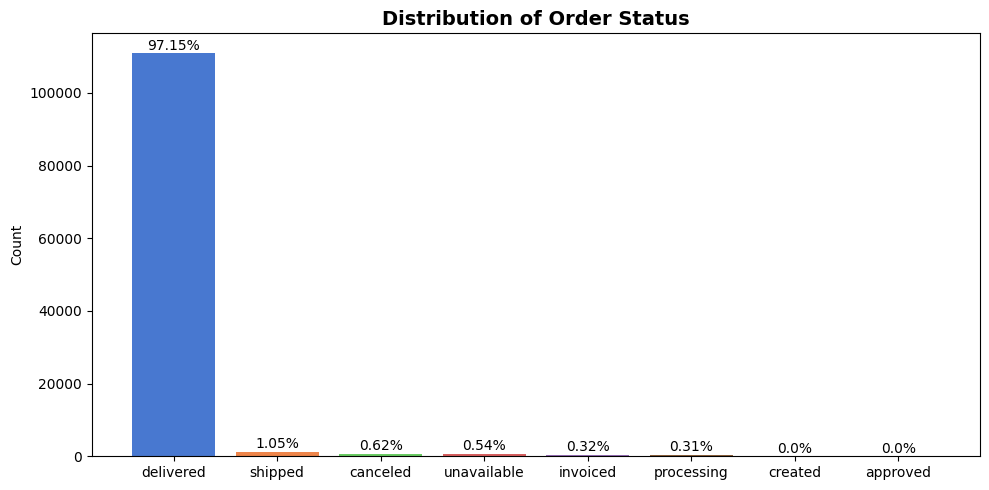

In [35]:
plot_distribution(status_counts, "Distribution of Order Status")

We can notice a big class imbalance.

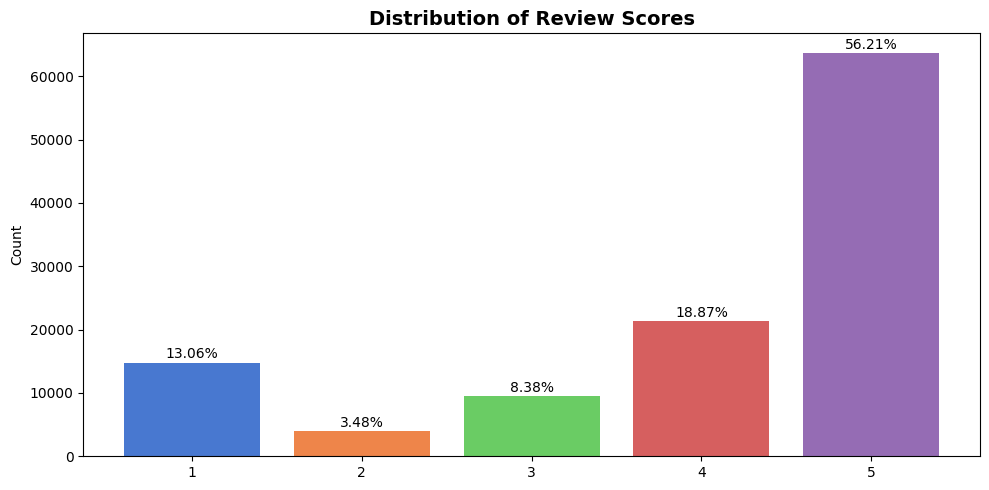

In [36]:
plot_distribution(df.review_score.value_counts().sort_index(), "Distribution of Review Scores")

Meaningful number of 1-stars. would be interesting to see why.

In [37]:
df.product_category_grouped.value_counts()

product_category_grouped
home_comfort          18764
leisure_media         18616
electronics           17266
health_beauty         16274
others                15472
furniture             11015
construction_tools     7220
fashion                3759
home_appliances        2105
food_drink             1187
Name: count, dtype: int64

In [38]:
cat_reviews = df.dropna(subset=["review_score", "product_category_grouped"]).groupby(
    "product_category_grouped"
).agg(
    avg_score=("review_score", "mean"),
    count=("review_score", "count")
).query("count >= 50").sort_values("avg_score")

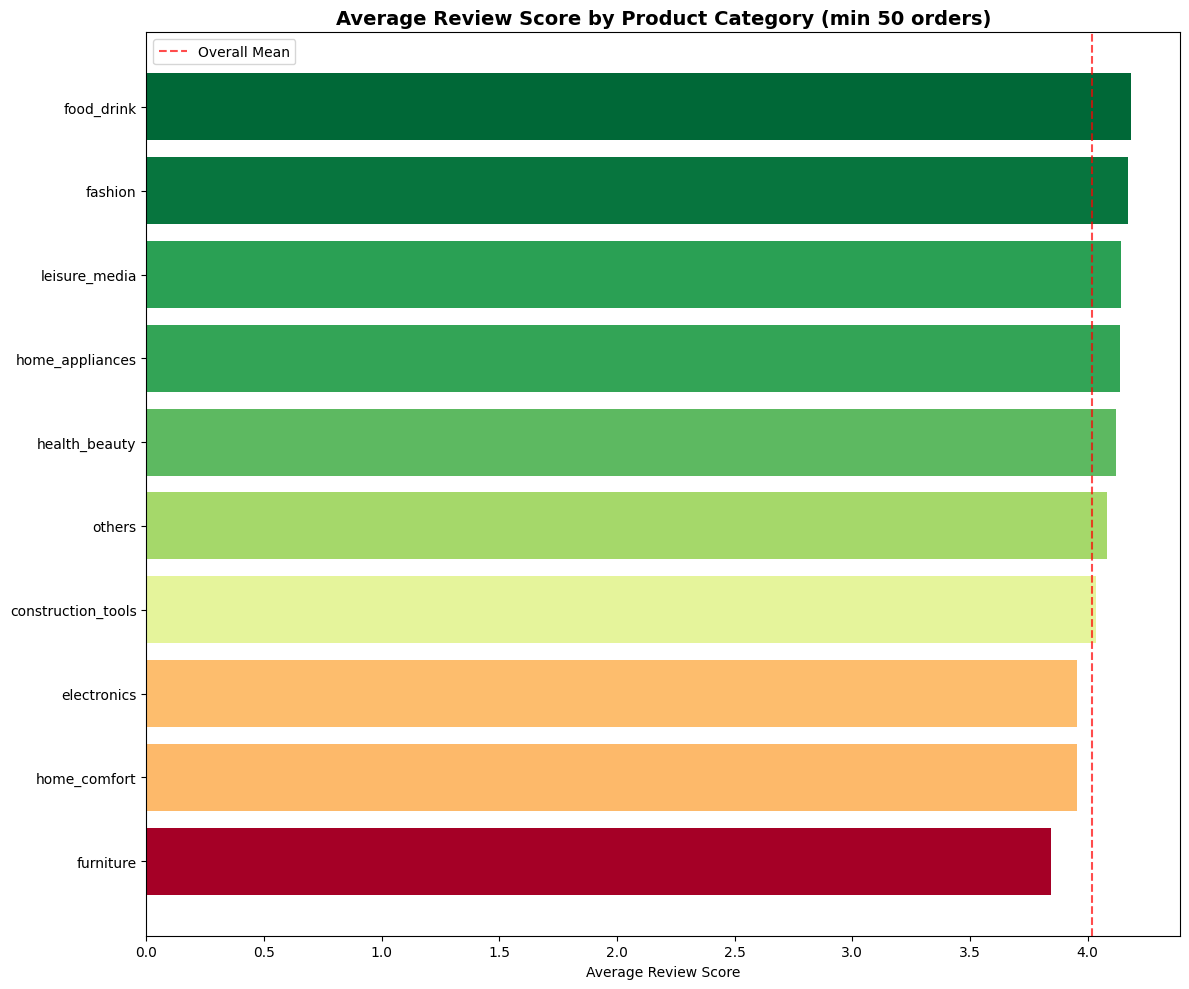

In [39]:
fig, ax = plt.subplots(figsize=(12, 10))
colors = plt.cm.RdYlGn((cat_reviews["avg_score"] - cat_reviews["avg_score"].min()) /
                         (cat_reviews["avg_score"].max() - cat_reviews["avg_score"].min()))
ax.barh(cat_reviews.index, cat_reviews["avg_score"], color=colors)
ax.set_xlabel("Average Review Score")
ax.set_title("Average Review Score by Product Category (min 50 orders)", fontsize=14, fontweight="bold")
ax.axvline(x=df["review_score"].mean(), color="red", linestyle="--", alpha=0.7, label="Overall Mean")
ax.legend()
plt.tight_layout()
plt.show()

## Check for outliers

In [40]:
def draw_plots(plot_type, df, features, rows,columns,path = ""):
    shape = len(features)
    plt.figure(figsize=(14, 8))
    
    for i,feature in enumerate(features,1):
        plt.subplot(rows,columns,i)

        if(plot_type == "hist"):
            # Histogram (counts)
            plt.hist(df[feature], bins=30, density=False)
            plt.title(f'Histogram of {feature}')
            plt.xlabel(feature)
            plt.ylabel('Frequency')
        elif(plot_type == "box"):
            plt.boxplot(df[feature], vert=False)
            plt.title(f'Boxplot of {feature}')
            plt.xlabel(feature)

    plt.tight_layout()
    if(path):
        plt.savefig(path)
    plt.show()

## Distribution of Late Deliveries

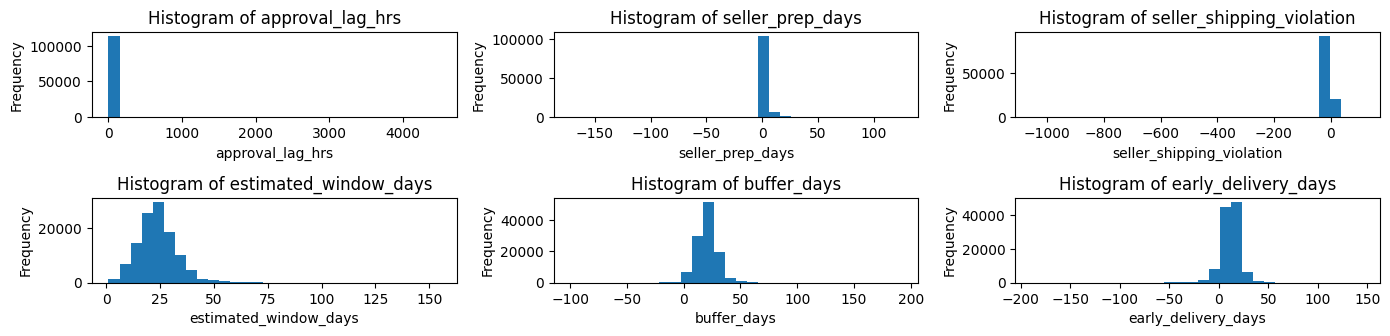

In [41]:
draw_plots("hist", df, engineered_date_cols, 5, 3)

In [42]:
df[engineered_date_cols + ["review_score"]].head(2)

,approval_lag_hrs,seller_prep_days,seller_shipping_violation,estimated_window_days,buffer_days,early_delivery_days,review_score
0,0.178333,2.0,-2.0,15,13.0,7.0,4.0
1,30.713889,0.0,-4.0,19,17.0,5.0,4.0


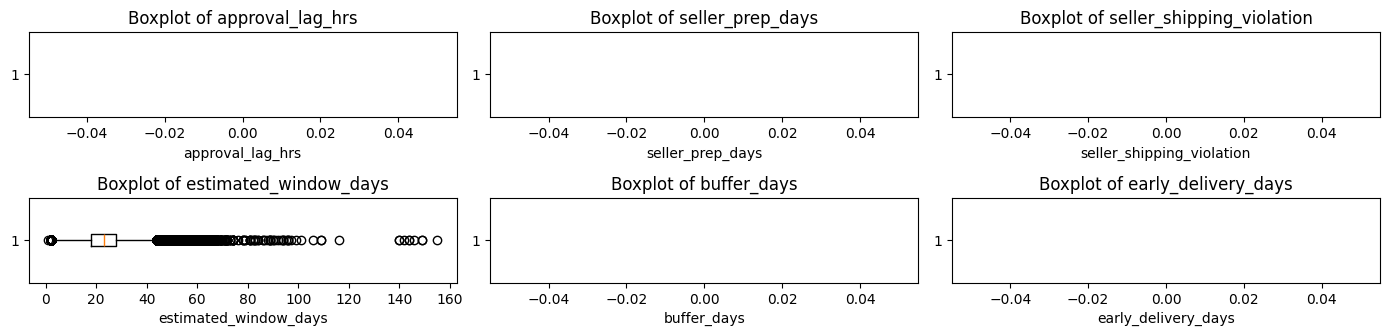

In [43]:
draw_plots("box", df, engineered_date_cols, 5, 3)

In [44]:
df['delivery_status'] = pd.cut(df['early_delivery_days'],
    bins=[-np.inf, -7, 0, 7, np.inf],                                                                                                                          
    labels=['Very Late', 'Late', 'On Time', 'Early'])
df['delivery_status'].value_counts()

delivery_status
Early        76897
On Time      23567
Late          6201
Very Late     4174
Name: count, dtype: int64

<Axes: xlabel='delivery_status'>

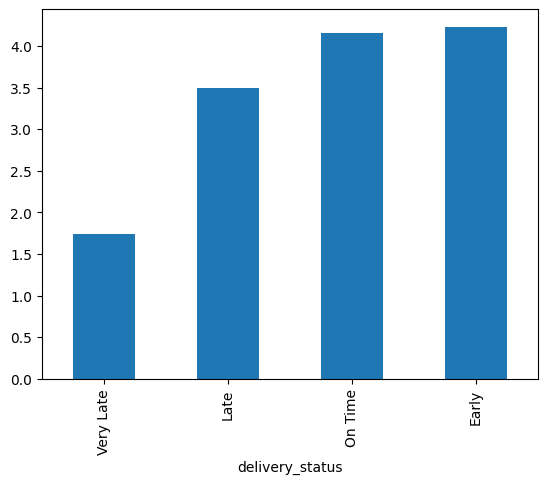

In [45]:
df.groupby('delivery_status')['review_score'].mean().plot(kind='bar')

<Axes: title={'center': 'review_score'}, xlabel='delivery_status'>

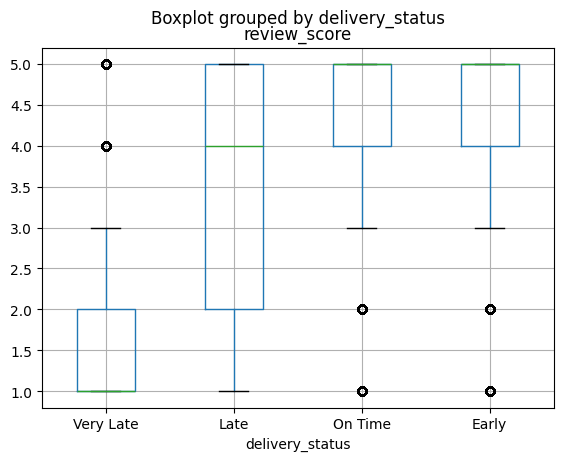

In [46]:
df.boxplot(column='review_score', by='delivery_status') 

In [47]:
delay_cols = ['approval_lag_hrs', 'seller_prep_days', 'seller_shipping_violation',
                'estimated_window_days', 'buffer_days', 'early_delivery_days']      
df[delay_cols + ['review_score']].corr()['review_score'].sort_values()

seller_prep_days            -0.149596
estimated_window_days       -0.060676
seller_shipping_violation   -0.059083
approval_lag_hrs            -0.027302
buffer_days                  0.000157
early_delivery_days          0.229030
review_score                 1.000000
Name: review_score, dtype: float64

# Feature Engineering

In [48]:
# Target
df['is_late'] = (df['early_delivery_days'] < 0).astype(int)                                                                                                    

In [49]:
df.is_late.value_counts()  / df.shape[0]

is_late
0    0.923255
1    0.076745
Name: count, dtype: float64

In [50]:
df.early_delivery_days.describe()

count    110839.000000
mean         11.035809
std          10.159965
min        -189.000000
25%           6.000000
50%          12.000000
75%          16.000000
max         146.000000
Name: early_delivery_days, dtype: float64

the above two will be my predictors

In [51]:
categorical_variables = df.select_dtypes(include=['object', 'category']).columns.tolist()
df[categorical_variables].head()

,order_id,customer_id,order_status,customer_unique_id,customer_city,customer_state,product_id,seller_id,product_category_name,product_category_name_english,seller_city,seller_state,payment_type,product_category_grouped,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,utilidades_domesticas,housewares,maua,SP,credit_card,home_comfort,On Time
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,af07308b275d755c9edb36a90c618231,barreiras,BA,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,perfumaria,perfumery,belo horizonte,SP,boleto,health_beauty,On Time
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,automotivo,auto,guariba,SP,credit_card,others,Early
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,pet_shop,pet_shop,belo horizonte,MG,credit_card,others,Early
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,papelaria,stationery,mogi das cruzes,SP,credit_card,others,Early


In [52]:
df['same_state'] = (df['customer_state'] == df['seller_state']).astype(int)
df.same_state.value_counts()

same_state
0    73109
1    40983
Name: count, dtype: int64

In [53]:
model_categorical_columns = ["order_status","product_category_grouped","delivery_status","same_state"]
model_categorical_columns = ["product_category_grouped", "same_state"]

In [54]:
y_class = "is_late"
y_reg = "early_delivery_days"
model_numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
model_numerical_columns.remove(y_class)
model_numerical_columns.remove(y_reg)
model_numerical_columns.remove("review_score")
model_numerical_columns.remove("seller_shipping_violation")
model_numerical_columns.remove("buffer_days")
model_numerical_columns.remove("same_state")
model_numerical_columns

['order_item_id',
 'price',
 'freight_value',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'payment_installments',
 'payment_value',
 'approval_lag_hrs',
 'seller_prep_days',
 'estimated_window_days']

## Encode Categorical Columns

In [55]:
df = df[df['order_status'] == 'delivered']                

In [56]:
for col in model_categorical_columns:
    n_unique = df[col].nunique()
    print(f"{col}: {n_unique} unique values")

product_category_grouped: 10 unique values
same_state: 2 unique values


In [57]:
print(df['product_category_grouped'].isna().sum() )
print(df['product_category_grouped'].isna().sum() / df.shape[0] * 100)

1567
1.4137495488993144


In [58]:
df = df.dropna(subset=['product_category_grouped'])

In [59]:
print(df['product_category_grouped'].isna().sum() )
print(df['product_category_grouped'].isna().sum() / df.shape[0] * 100)

0
0.0


In [60]:
df[model_numerical_columns].isna().sum()

order_item_id                  0
price                          0
freight_value                  0
product_name_lenght            0
product_description_lenght     0
product_photos_qty             0
product_weight_g               1
product_length_cm              1
product_height_cm              1
product_width_cm               1
payment_installments           3
payment_value                  3
approval_lag_hrs              14
seller_prep_days              16
estimated_window_days          0
dtype: int64

In [61]:
# fill numerical missing values with median
df[model_numerical_columns] = df[model_numerical_columns].fillna(df[model_numerical_columns].median())

In [62]:
df[model_numerical_columns].isna().sum()

order_item_id                 0
price                         0
freight_value                 0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
payment_installments          0
payment_value                 0
approval_lag_hrs              0
seller_prep_days              0
estimated_window_days         0
dtype: int64

## Final Inspection before modelling

In [63]:
df[model_categorical_columns].head()

,product_category_grouped,same_state
0,home_comfort,1
1,health_beauty,0
2,others,0
3,others,0
4,others,1


In [64]:
df.groupby('order_id')['product_category_grouped'].nunique().value_counts()  

product_category_grouped
1    94553
2      564
3       10
Name: count, dtype: int64

In [65]:
# one hot encode product_category_grouped
df = pd.get_dummies(df, columns=['product_category_grouped'], drop_first=True)

In [66]:
model_categorical_columns.remove("product_category_grouped")
# add all one hot encoded columns to model_categorical_columns
model_categorical_columns += [col for col in df.columns if col.startswith("product_category_grouped_")]

In [67]:
X = df[model_categorical_columns + model_numerical_columns]

In [68]:
X.head(1).to_clipboard()

In [69]:
df[y_class].value_counts()

is_late
0    100663
1      8610
Name: count, dtype: int64

In [70]:
df[y_reg].describe()

count    109265.000000
mean         11.043811
std          10.153683
min        -189.000000
25%           6.000000
50%          12.000000
75%          16.000000
max         146.000000
Name: early_delivery_days, dtype: float64

### Winsorizing y_reg because huge difference

In [71]:
df[y_reg] = df[y_reg].fillna(df[y_reg].median())

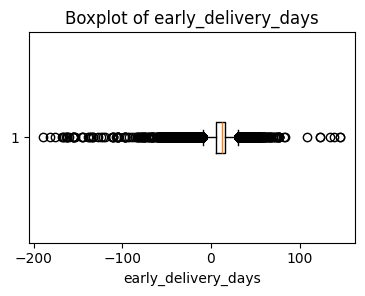

In [72]:
draw_plots("box", df, [y_reg], 3, 4)

In [73]:
lower = df['early_delivery_days'].quantile(0.01) 
upper = df['early_delivery_days'].quantile(0.99) 
lower, upper

(np.float64(-19.0), np.float64(35.0))

In [74]:
df['early_delivery_days'] = df['early_delivery_days'].clip(lower, upper)

In [75]:
df[y_reg].describe()

count    109273.000000
mean         11.122363
std           8.922165
min         -19.000000
25%           6.000000
50%          12.000000
75%          16.000000
max          35.000000
Name: early_delivery_days, dtype: float64

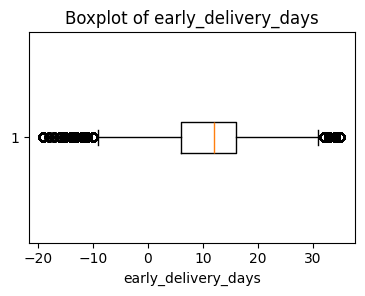

In [76]:
draw_plots("box", df, [y_reg], 3, 4)

## Train Test Split

In [77]:
X.shape

(109273, 25)

In [78]:
y_reg = df[y_reg]
y_class = df[y_class]

In [79]:
y_reg.shape, y_class.shape

((109273,), (109273,))

In [80]:
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
      X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
  )

In [81]:
X_train.shape, X_test.shape, y_class_train.shape, y_class_test.shape, y_reg_train.shape, y_reg_test.shape

((87418, 25), (21855, 25), (87418,), (21855,), (87418,), (21855,))

## Scaling Data

In [82]:
scaler = StandardScaler() 

In [83]:
model_categorical_columns, model_numerical_columns

(['same_state',
  'product_category_grouped_electronics',
  'product_category_grouped_fashion',
  'product_category_grouped_food_drink',
  'product_category_grouped_furniture',
  'product_category_grouped_health_beauty',
  'product_category_grouped_home_appliances',
  'product_category_grouped_home_comfort',
  'product_category_grouped_leisure_media',
  'product_category_grouped_others'],
 ['order_item_id',
  'price',
  'freight_value',
  'product_name_lenght',
  'product_description_lenght',
  'product_photos_qty',
  'product_weight_g',
  'product_length_cm',
  'product_height_cm',
  'product_width_cm',
  'payment_installments',
  'payment_value',
  'approval_lag_hrs',
  'seller_prep_days',
  'estimated_window_days'])

In [84]:
X_train_scaled = X_train.copy()            
X_test_scaled = X_test.copy()

In [85]:
X_train_scaled[model_numerical_columns] = scaler.fit_transform(X_train[model_numerical_columns])

In [86]:
X_test_scaled[model_numerical_columns] = scaler.transform(X_test[model_numerical_columns])

In [87]:
X_train.head()

,same_state,product_category_grouped_electronics,product_category_grouped_fashion,product_category_grouped_food_drink,product_category_grouped_furniture,product_category_grouped_health_beauty,product_category_grouped_home_appliances,product_category_grouped_home_comfort,product_category_grouped_leisure_media,product_category_grouped_others,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_installments,payment_value,approval_lag_hrs,seller_prep_days,estimated_window_days
52257,0,False,False,False,False,False,False,False,False,False,1.0,49.9,26.43,59.0,341.0,2.0,1850.0,37.0,22.0,40.0,1.0,76.33,54.323333,1.0,38
90292,1,False,False,False,False,False,False,False,False,False,1.0,59.9,13.44,59.0,341.0,2.0,1850.0,37.0,22.0,40.0,10.0,146.68,0.210556,2.0,24
96678,0,False,False,False,False,False,False,False,False,False,1.0,465.0,25.79,28.0,388.0,2.0,3000.0,30.0,30.0,20.0,3.0,490.79,0.393333,0.0,43
38278,0,True,False,False,False,False,False,False,False,False,1.0,77.9,18.65,33.0,256.0,1.0,180.0,17.0,10.0,13.0,1.0,96.55,37.397778,0.0,29
29521,0,False,False,False,False,True,False,False,False,False,1.0,23.9,14.52,57.0,1271.0,5.0,225.0,45.0,10.0,14.0,3.0,38.42,0.518056,1.0,26


In [88]:
X_train_scaled[:5]

,same_state,product_category_grouped_electronics,product_category_grouped_fashion,product_category_grouped_food_drink,product_category_grouped_furniture,product_category_grouped_health_beauty,product_category_grouped_home_appliances,product_category_grouped_home_comfort,product_category_grouped_leisure_media,product_category_grouped_others,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_installments,payment_value,approval_lag_hrs,seller_prep_days,estimated_window_days
52257,0,False,False,False,False,False,False,False,False,False,-0.280206,-0.382093,0.412343,1.018686,-0.685331,-0.120609,-0.064989,0.423233,0.402915,1.454910,-0.730707,-0.387975,2.075446,-0.374638,1.649564
90292,1,False,False,False,False,False,False,False,False,False,-0.280206,-0.327754,-0.416319,1.018686,-0.685331,-0.120609,-0.064989,0.423233,0.402915,1.454910,2.435593,-0.124396,-0.489306,-0.095055,0.060773
96678,0,False,False,False,False,False,False,False,False,False,-0.280206,1.873530,0.371516,-2.077007,-0.613118,-0.120609,0.242715,-0.010920,0.999179,-0.258953,-0.027085,1.164872,-0.480643,-0.654221,2.216989
38278,0,True,False,False,False,False,False,False,False,False,-0.280206,-0.229943,-0.083961,-1.577702,-0.815930,-0.701478,-0.511828,-0.817205,-0.491480,-0.858805,-0.730707,-0.312217,1.273235,-0.654221,0.628199
29521,0,False,False,False,False,True,False,False,False,False,-0.280206,-0.523375,-0.347423,0.818964,0.743575,1.621999,-0.499787,0.919408,-0.491480,-0.773111,-0.027085,-0.530011,-0.474732,-0.374638,0.287743


# Modeling

Class imbalance in the classification task, need to keep in mind.

In [175]:
y_class_train.value_counts() / y_class_train.shape[0]

is_late
0    0.921206
1    0.078794
Name: count, dtype: float64

## Classification

### Baseline Model

In [223]:
def plot_roc_curve(y_true, y_pred_proba, title="ROC Curve"):
      """
      Plot ROC curve with threshold markers.
   
      Parameters:
      -----------
      y_true : array-like
          True binary labels (0 or 1)
      y_pred_proba : array-like
          Predicted probabilities for positive class
      title : str
          Plot title
      """
      fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
      roc_auc = auc(fpr, tpr)

      plt.figure(figsize=(10, 8))
      plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
      plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')

      # Mark threshold 0.5
      idx_50 = np.argmin(np.abs(thresholds - 0.5))
      plt.plot(fpr[idx_50], tpr[idx_50], 'ro', markersize=8, label='Threshold = 0.5')

      # Mark best F1
      f1_scores = 2 * (tpr * (1 - fpr)) / (tpr + (1 - fpr) + 1e-10)
      idx_best = np.argmax(f1_scores)
      plt.plot(fpr[idx_best], tpr[idx_best], 'g*', markersize=15,
               label=f'Best F1 (threshold = {thresholds[idx_best]:.3f})')

      plt.xlabel('False Positive Rate', fontsize=12)
      plt.ylabel('True Positive Rate (Recall)', fontsize=12)
      plt.title(title, fontsize=14)
      plt.legend(loc='lower right')
      plt.grid(True, alpha=0.3)
      plt.tight_layout()
      plt.show()

      return fpr, tpr, thresholds


def print_threshold_metrics(y_true, y_pred_proba, thresholds_to_check=[0.2, 0.3, 0.4,
0.5]):
    """
    Print precision, recall, F1 for different thresholds.

    Parameters:
    -----------
    y_true : array-like
        True labels
    y_pred_proba : array-like
        Predicted probabilities
    thresholds_to_check : list
        Thresholds to evaluate
    """
    print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1 Score':<12}")
    print("-" * 48)

    for threshold in thresholds_to_check:
        y_pred = (y_pred_proba >= threshold).astype(int)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        print(f"{threshold:<12.3f} {precision:<12.3f} {recall:<12.3f} {f1:<12.3f}")

In [233]:
def classification_model(model ,X_train, y_train, X_test, y_test, threshold=0.5):
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_predict = y_pred_proba > threshold
    accuracy = accuracy_score(y_test, y_predict)
    precision = precision_score(y_test, y_predict)
    recall = recall_score(y_test, y_predict)
    f1 = f1_score(y_test, y_predict)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    plot_roc_curve(y_test, y_pred_proba, title="ROC Curve")
    print_threshold_metrics(y_test, y_pred_proba, thresholds_to_check=[0.1, 0.2, 0.3, 0.4,0.5])
    results = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": auc
    }
    return results

def regression_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_predict = model.predict(X_test)
    mse = mean_squared_error(y_test, y_predict)
    mae = mean_absolute_error(y_test, y_predict)
    r2 = r2_score(y_test, y_predict)

    results = {
        "mean_squared_error": mse,
        "mean_absolute_error": mae,
        "r2_score": r2
    }
    return results

def get_trained_classification_model(model, X_train, y_train):
    model.fit(X_train, y_train)
    return model

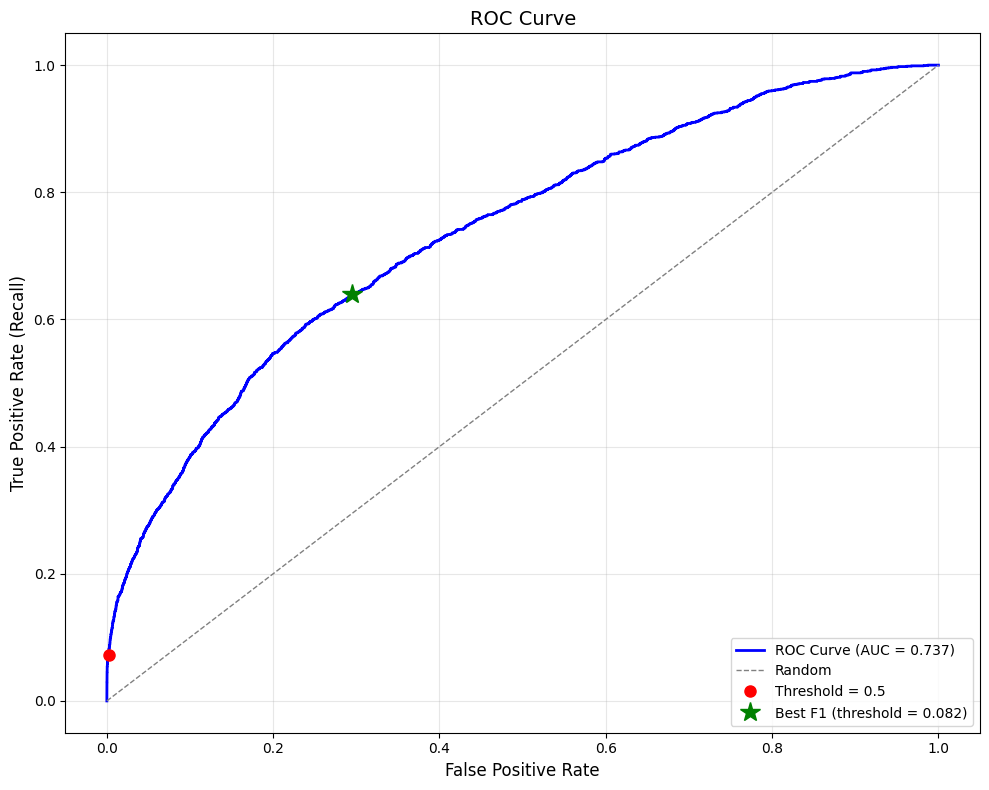

Threshold    Precision    Recall       F1 Score    
------------------------------------------------
0.100        0.190        0.542        0.282       
0.200        0.356        0.236        0.284       
0.300        0.555        0.141        0.224       
0.400        0.663        0.099        0.173       
0.500        0.734        0.072        0.131       
{'accuracy': 0.924822695035461, 'precision': 0.7337278106508875, 'recall': 0.07200929152148665, 'f1_score': 0.13114754098360656, 'roc_auc': 0.7369994761318072}


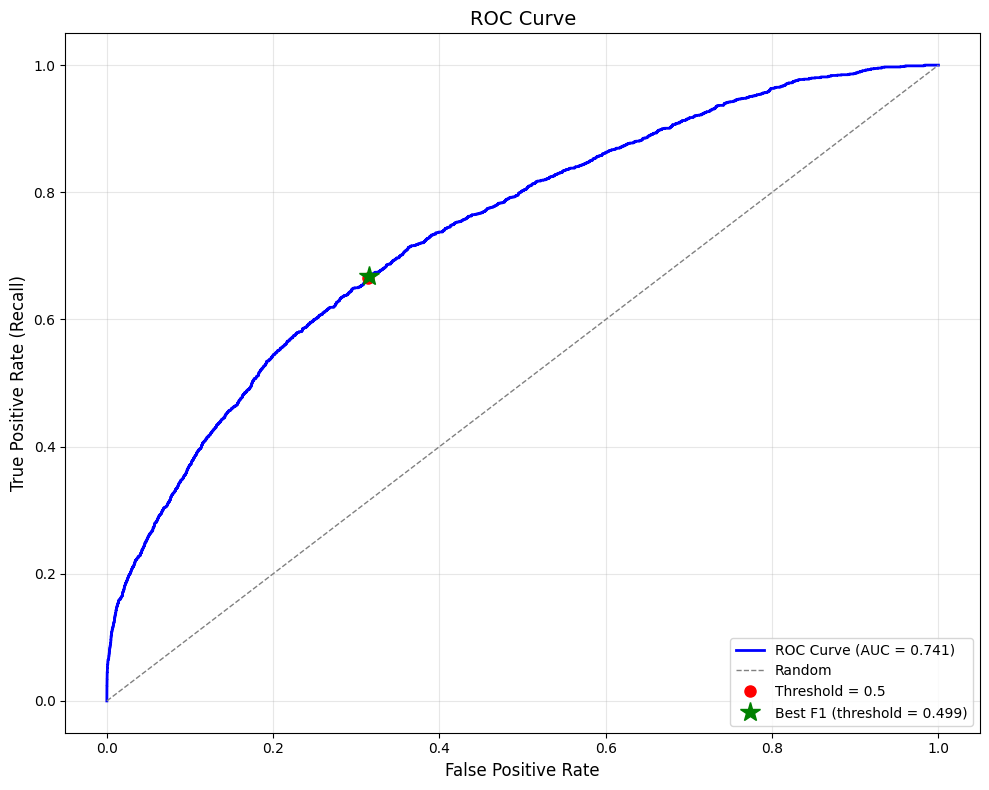

Threshold    Precision    Recall       F1 Score    
------------------------------------------------
0.100        0.081        0.999        0.149       
0.200        0.086        0.986        0.158       
0.300        0.098        0.936        0.178       
0.400        0.118        0.819        0.206       
0.500        0.153        0.666        0.249       
{'accuracy': 0.6840539922214596, 'precision': 0.15331103678929767, 'recall': 0.6655052264808362, 'f1_score': 0.24921169946721758, 'roc_auc': 0.7408203795514763}


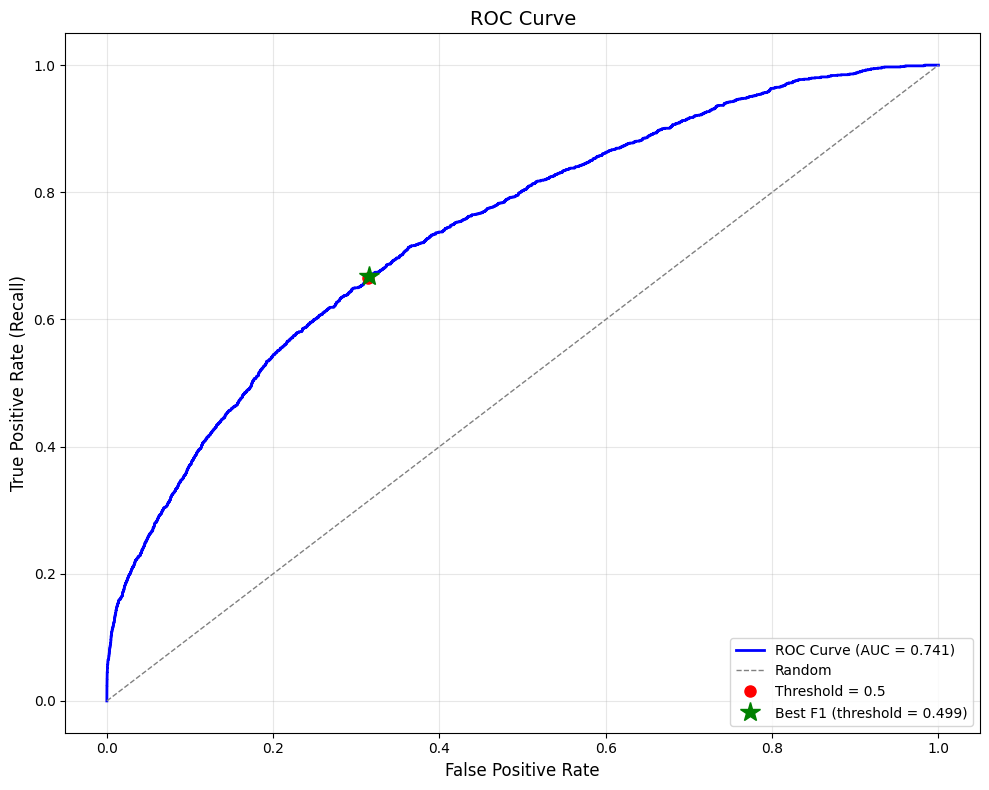

Threshold    Precision    Recall       F1 Score    
------------------------------------------------
0.100        0.081        0.999        0.149       
0.200        0.086        0.986        0.158       
0.300        0.098        0.936        0.178       
0.400        0.118        0.819        0.206       
0.500        0.153        0.666        0.249       
{'accuracy': 0.8223747426218256, 'precision': 0.21030042918454936, 'recall': 0.45528455284552843, 'f1_score': 0.2877064220183486, 'roc_auc': 0.7408203795514763}


In [228]:
print(classification_model(LogisticRegression(max_iter=1000, random_state=42),X_train_scaled, y_class_train, X_test_scaled, y_class_test, threshold=0.5))

print(classification_model(LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
                    ,X_train_scaled, y_class_train, X_test_scaled, y_class_test, threshold=0.5))

print(classification_model(LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
                    ,X_train_scaled, y_class_train, X_test_scaled, y_class_test, threshold=0.6))

In [178]:
print(regression_model(LinearRegression(),X_train_scaled, y_reg_train, X_test_scaled, y_reg_test))

{'mean_squared_error': 43.000900577734534, 'mean_absolute_error': 4.453319758363585, 'r2_score': 0.46066858530602883}


In [179]:
classifiers = {
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                             use_label_encoder=False, eval_metric="logloss",
                             random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                random_state=42, verbose=-1, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, max_depth=5,
                                                    learning_rate=0.1, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=10,
                                            random_state=42, n_jobs=-1),
    "SGD": SGDClassifier(loss="modified_huber", max_iter=1000, random_state=42, n_jobs=-1),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
}

balancing_techniques = {
    "None": None,
    "SMOTE": SMOTE(random_state=42),
    "SVMSMOTE": SVMSMOTE(random_state=42),
    "BorderlineSMOTE": BorderlineSMOTE(random_state=42),
    "SMOTEENN": SMOTEENN(random_state=42),
    "ADASYN": ADASYN(random_state=42),
    "SMOTETomek": SMOTETomek(random_state=42),
    # Undersampling techniques
    "TomekLinks": TomekLinks(),
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
    "NearMiss": NearMiss(),
    "EditedNearestNeighbours": EditedNearestNeighbours()
}

In [180]:
thresholds = [0.3, 0.5, 0.7]
classification_results = {}


for balancer_name, balancer in balancing_techniques.items():
    if balancer is not None:
        print(f"Before applying {balancer_name}:")
        print(f"  - Samples: {X_train_scaled.shape[0]}")
        print(f"  - Classes: {np.unique(y_class_train, return_counts=True)[1]}")
        print("Percentage:  ", (y_class_train.value_counts() / y_class_train.shape[0] * 100).round(2).to_dict())
        X_train_bal, y_train_bal = balancer.fit_resample(X_train_scaled, y_class_train)
        print(f"After applying {balancer_name}:")
        print(f"  - Samples: {X_train_bal.shape[0]}")
        print(f"  - Classes: {np.unique(y_train_bal, return_counts=True)[1]}")
        print("Percentage:  ", (y_train_bal.value_counts() / y_train_bal.shape[0] * 100).round(2).to_dict())

    else:
        X_train_bal, y_train_bal = X_train_scaled, y_class_train

    results_list = []
    for model_name, model in classifiers.items():
        for threshold in thresholds:
            print(f"\nTraining {model_name} with {balancer_name} balancing and threshold {threshold}:")
            results = classification_model(model, X_train_bal, y_train_bal, X_test_scaled, y_class_test, threshold=threshold)
            print(f"Results: {results}")
            results_list.append({
                "model": model_name,
                "balancing": balancer_name,
                "threshold": threshold,
                **results
            })
    classification_results[balancer_name] = results_list
    
results_df = pd.DataFrame([res for res_list in classification_results.values() for res in res_list])
results_df.sort_values(by="roc_auc", ascending=False, inplace=True)
results_df.head(10)


Training XGBoost with None balancing and threshold 0.3:
Results: {'accuracy': 0.9282086479066575, 'precision': 0.6473988439306358, 'recall': 0.1951219512195122, 'f1_score': 0.2998661311914324, 'roc_auc': 0.7820775812969191}

Training XGBoost with None balancing and threshold 0.5:
Results: {'accuracy': 0.9304506977808282, 'precision': 0.8506944444444444, 'recall': 0.14227642276422764, 'f1_score': 0.24378109452736318, 'roc_auc': 0.7820775812969191}

Training XGBoost with None balancing and threshold 0.7:
Results: {'accuracy': 0.9284374285060627, 'precision': 0.9647058823529412, 'recall': 0.09523809523809523, 'f1_score': 0.1733615221987315, 'roc_auc': 0.7820775812969191}

Training LightGBM with None balancing and threshold 0.3:
Results: {'accuracy': 0.9278883550674902, 'precision': 0.6351851851851852, 'recall': 0.1991869918699187, 'f1_score': 0.3032714412024757, 'roc_auc': 0.7838788289004717}

Training LightGBM with None balancing and threshold 0.5:
Results: {'accuracy': 0.93017616106154

,model,balancing,threshold,accuracy,precision,recall,f1_score,roc_auc
6,GradientBoosting,None,0.3,0.927660,0.626571,0.202671,0.306275,0.783949
7,GradientBoosting,None,0.5,0.930405,0.821086,0.149245,0.252580,0.783949
8,GradientBoosting,None,0.7,0.928941,0.928934,0.106272,0.190724,0.783949
3,LightGBM,None,0.3,0.927888,0.635185,0.199187,0.303271,0.783879
4,LightGBM,None,0.5,0.930176,0.837931,0.141115,0.241551,0.783879
5,LightGBM,None,0.7,0.928300,0.947977,0.095238,0.173087,0.783879
132,GradientBoosting,TomekLinks,0.3,0.927294,0.614853,0.206736,0.309431,0.783121
133,GradientBoosting,TomekLinks,0.5,0.930130,0.794562,0.152729,0.256210,0.783121
134,GradientBoosting,TomekLinks,0.7,0.929170,0.935000,0.108595,0.194589,0.783121
127,XGBoost,TomekLinks,0.5,0.930130,0.813505,0.146922,0.248893,0.782611


In [181]:
results_df.to_csv("./outputs/classification_results.csv", index=False)

In [188]:
regression_results = {}
regression_models = {
    "XGBoost": XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
    "Linear Regression": LinearRegression()
}

In [189]:
for model_name, model in regression_models.items():
    print(f"\nTraining {model_name} for regression:")
    results = regression_model(model, X_train_scaled, y_reg_train, X_test_scaled, y_reg_test)
    regression_results[model_name] = results
    print(f"Results: {results}")


Training XGBoost for regression:
Results: {'mean_squared_error': 39.47946213691662, 'mean_absolute_error': 4.233491200577485, 'r2_score': 0.5048356225198367}

Training Random Forest for regression:
Results: {'mean_squared_error': 44.686991239567526, 'mean_absolute_error': 4.632846257754698, 'r2_score': 0.4395210825855964}

Training Gradient Boosting for regression:
Results: {'mean_squared_error': 39.401392265929324, 'mean_absolute_error': 4.232546916294315, 'r2_score': 0.5058148004765506}

Training Linear Regression for regression:
Results: {'mean_squared_error': 43.000900577734534, 'mean_absolute_error': 4.453319758363585, 'r2_score': 0.46066858530602883}


In [190]:
# convert to dataframe and save
regression_results_df = pd.DataFrame.from_dict(regression_results, orient='index').reset_index().rename(columns={'index': 'model'})
regression_results_df.to_csv("./outputs/regression_results.csv", index=False)

In [191]:
regression_results_df

,model,mean_squared_error,mean_absolute_error,r2_score
0,XGBoost,39.479462,4.233491,0.504836
1,Random Forest,44.686991,4.632846,0.439521
2,Gradient Boosting,39.401392,4.232547,0.505815
3,Linear Regression,43.000901,4.453320,0.460669


## AutoML

### Classification

In [195]:
def run_automl(X_train, y_train, X_test, y_test, time_budget=180, task="classification"):
    automl = flaml.AutoML()
    
    # 1. Configure settings based on task
    settings = {
        "time_budget": time_budget,
        "metric": 'roc_auc' if task == "classification" else 'mae',
        "task": task,
        "seed": 42,
    }
    
    automl.fit(X_train=X_train, y_train=y_train, **settings)
    predictions = automl.predict(X_test)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    if task == "classification":
        probs = automl.predict_proba(X_test)[:, 1]
        
        # Confusion Matrix
        sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title("Confusion Matrix")
        
        # ROC Curve
        fpr, tpr, _ = roc_curve(y_test, probs)
        axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, probs):.4f}')
        axes[1].plot([0, 1], 'r--')
        axes[1].set_title("ROC Curve")
        axes[1].legend()

    else:
        # Regression Plot: Predicted vs Actual
        sns.scatterplot(x=y_test, y=predictions, ax=axes[0])
        axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
        axes[0].set_title("Actual vs Predicted")
        
        # Residual Plot
        residuals = y_test - predictions
        sns.histplot(residuals, kde=True, ax=axes[1])
        axes[1].set_title(f"Residuals (R2: {r2_score(y_test, predictions):.2f})")

    plt.tight_layout()
    plt.show()

    return automl

[flaml.automl.logger: 04-04 19:37:17] {2375} INFO - task = regression
[flaml.automl.logger: 04-04 19:37:17] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 04-04 19:37:17] {2489} INFO - Minimizing error metric: mae
[flaml.automl.logger: 04-04 19:37:17] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd']
[flaml.automl.logger: 04-04 19:37:17] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 04-04 19:37:17] {3046} INFO - Estimated sufficient time budget=2103s. Estimated necessary time budget=15s.
[flaml.automl.logger: 04-04 19:37:17] {3097} INFO -  at 0.5s,	estimator lgbm's best error=5.9405e+00,	best estimator lgbm's best error=5.9405e+00
[flaml.automl.logger: 04-04 19:37:17] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 04-04 19:37:17] {3097} INFO -  at 0.6s,	estimator lgbm's best error=5.9405e+00,	best estimator lgbm's best error=5.9405e+00
[flaml.automl.logger: 04-

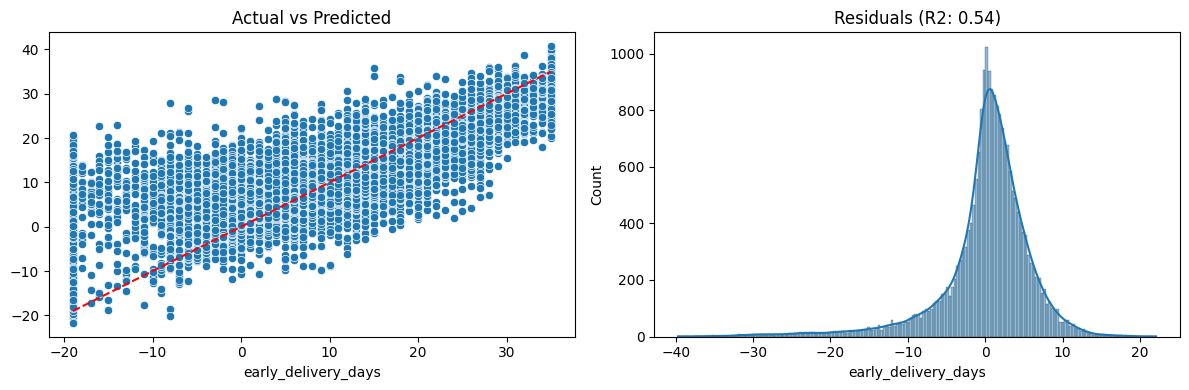

In [196]:
reg_automl = run_automl(X_train_scaled, y_reg_train, X_test_scaled, y_reg_test, time_budget=60 * 10, task="regression")

In [202]:
reg_results_data = {
    "Model": [reg_automl.best_estimator],
    "Best Config": [reg_automl.best_config],
    "Best Loss": [reg_automl.best_loss],# FLAML minimizes loss
    "R2 Score": [r2_score(y_reg_test, reg_automl.predict(X_test_scaled))]
}
reg_results_df = pd.DataFrame(reg_results_data)
reg_results_df.to_csv("automl_reg_results.csv", index=False)
reg_results_df.to_csv("automl_reg_results.csv", index=False)

[flaml.automl.logger: 04-04 19:47:29] {2375} INFO - task = classification
[flaml.automl.logger: 04-04 19:47:29] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 04-04 19:47:29] {2489} INFO - Minimizing error metric: 1-roc_auc
[flaml.automl.logger: 04-04 19:47:29] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 04-04 19:47:29] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 04-04 19:47:29] {3046} INFO - Estimated sufficient time budget=1754s. Estimated necessary time budget=41s.
[flaml.automl.logger: 04-04 19:47:29] {3097} INFO -  at 0.4s,	estimator lgbm's best error=3.7097e-01,	best estimator lgbm's best error=3.7097e-01
[flaml.automl.logger: 04-04 19:47:29] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 04-04 19:47:29] {3097} INFO -  at 0.4s,	estimator lgbm's best error=3.2279e-01,	best estimator lgbm's best error=3.2279e-01
[flaml.

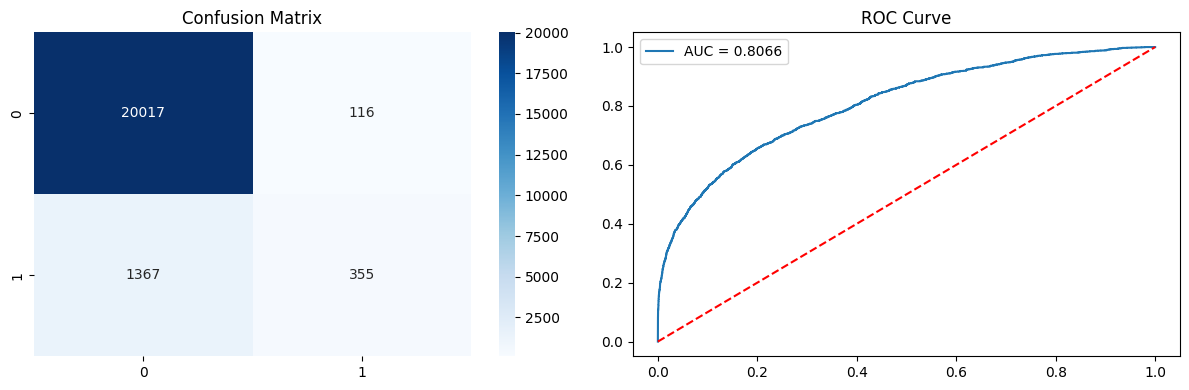

In [197]:
class_automl = run_automl(X_train_scaled, y_class_train, X_test_scaled, y_class_test, time_budget=60 * 10, task="classification")

In [206]:
class_results_data = {
    "Model": [class_automl.best_estimator],
    "Best Config": [class_automl.best_config],
    "Best Accuracy": [1 - class_automl.best_loss] # FLAML minimizes loss,
}
class_results_df = pd.DataFrame(class_results_data)
class_results_df.to_csv("automl_class_results.csv", index=False)

In [207]:
class_results_df

,Model,Best Config,Best Accuracy
0,xgboost,"{'n_estimators': 1341, 'max_leaves': 24, 'min_...",0.786637


In [208]:
reg_results_df

,Model,Best Config,Best Loss,R2 Score
0,xgb_limitdepth,"{'n_estimators': 2513, 'max_depth': 7, 'min_ch...",3.936143,0.539458


In [215]:
best_params = {
    'n_estimators': 1341, 
    'max_leaves': 24, 
    'min_child_weight': 2.295604945618853, 
    'learning_rate': 0.10274598978173108, 
    'subsample': 0.8894590090312318, 
    'colsample_bylevel': 1.0, 
    'colsample_bytree': 0.9472793968800469, 
    'reg_alpha': 0.05472800965266363, 
    'reg_lambda': 0.11894526523396565
}

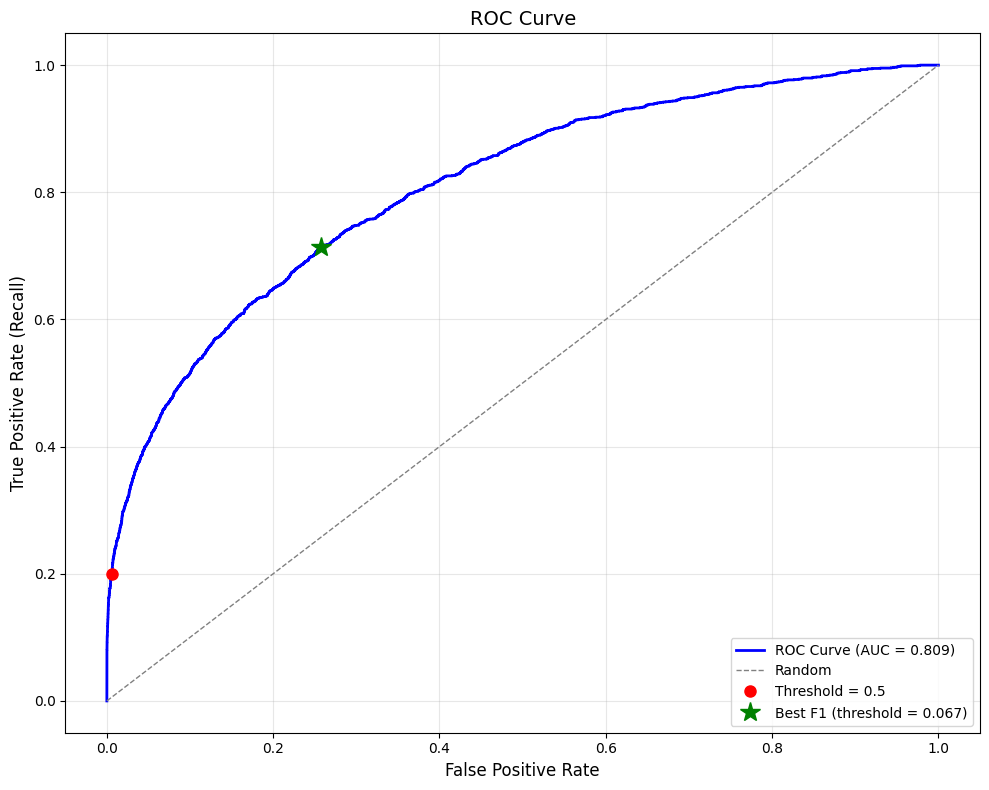

Threshold    Precision    Recall       F1 Score    
------------------------------------------------
0.100        0.246        0.606        0.350       
0.200        0.414        0.406        0.410       
0.300        0.555        0.302        0.391       
0.400        0.674        0.240        0.354       
0.500        0.750        0.199        0.314       


{'accuracy': 0.9316403568977351,
 'precision': 0.75,
 'recall': 0.1986062717770035,
 'f1_score': 0.3140495867768595,
 'roc_auc': 0.8089676358372456}

In [227]:
results = classification_model(xgb.XGBClassifier(**best_params, random_state=42, use_label_encoder=False), X_train_scaled, y_class_train, X_test_scaled, y_class_test, threshold=0.5)
results

In [229]:
best_params = {
    "scale_pos_weight": 11.5,  # (92% / 8%) = 11.5  
    'n_estimators': 1341, 
    'max_leaves': 24, 
    'min_child_weight': 2.295604945618853, 
    'learning_rate': 0.10274598978173108, 
    'subsample': 0.8894590090312318, 
    'colsample_bylevel': 1.0, 
    'colsample_bytree': 0.9472793968800469, 
    'reg_alpha': 0.05472800965266363, 
    'reg_lambda': 0.11894526523396565
}

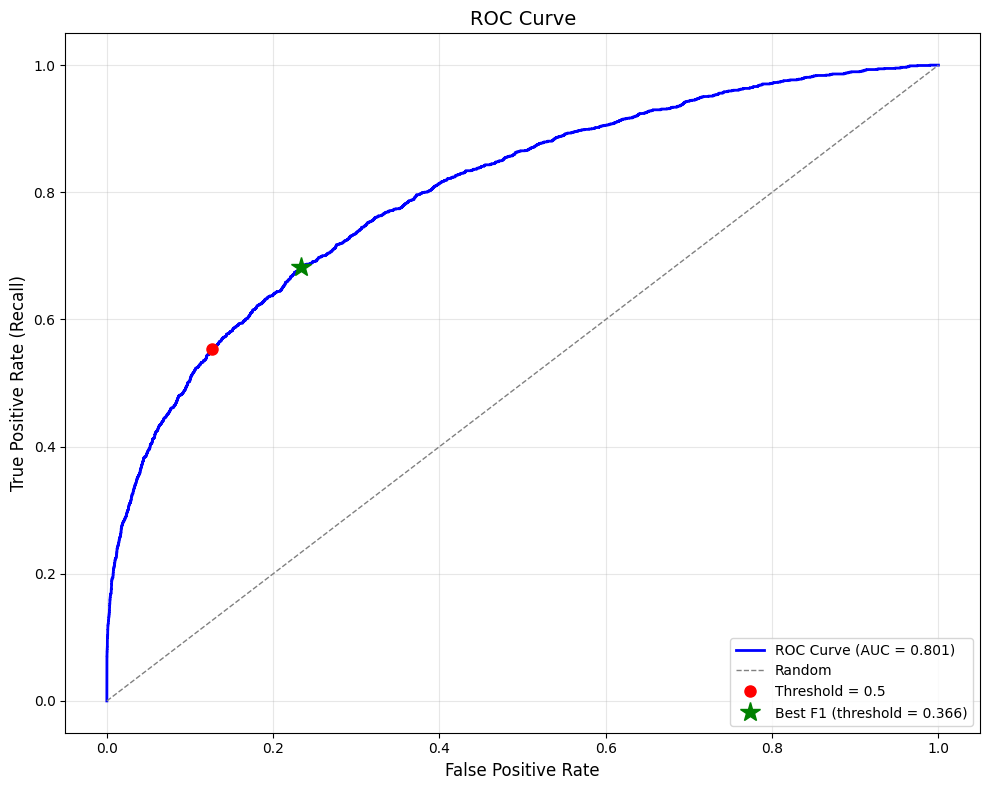

Threshold    Precision    Recall       F1 Score    
------------------------------------------------
0.100        0.111        0.916        0.199       
0.200        0.140        0.835        0.239       
0.300        0.173        0.739        0.280       
0.400        0.212        0.643        0.319       
0.500        0.272        0.553        0.364       


{'accuracy': 0.8478609013955617,
 'precision': 0.27158734682245655,
 'recall': 0.5534262485481998,
 'f1_score': 0.3643662779583254,
 'roc_auc': 0.8005770626495247}

In [230]:
results = classification_model(xgb.XGBClassifier(**best_params, random_state=42, use_label_encoder=False), X_train_scaled, y_class_train, X_test_scaled, y_class_test, threshold=0.5)
results

## Final Training

In [84]:
full_data_scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[model_numerical_columns] = full_data_scaler.fit_transform(X[model_numerical_columns])

In [3]:


def save_package(package, filepath):
    with open(filepath, 'wb') as f:
        pickle.dump(package, f)
    print(f"Package saved to {filepath}")

def load_package(filepath):
    with open(filepath, 'rb') as f:
        package = pickle.load(f)
    print(f"Package loaded from {filepath}")
    return package

In [86]:
def predict_with_threshold(model, X_data, threshold=0.2):                                 
      probabilities = model.predict_proba(X_data)[:, 1]  # Probability of positive class
      predictions = (probabilities >= threshold).astype(int)                                
  
      return predictions, probabilities 

In [ ]:
save_package(full_data_scaler, "./outputs/full_data_scaler.pkl")

Scaler saved to ./outputs/full_data_scaler.pkl


In [88]:
y_class_column = "is_late"

In [ ]:
model = get_trained_classification_model(xgb.XGBClassifier(**best_params, random_state=42, use_label_encoder=False), X_scaled, df[y_class_column])

In [ ]:
save_package(model, "./outputs/final_xgb_model.pkl")

Model saved to ./outputs/final_xgb_model.pkl


In [89]:
X.to_csv("./outputs/final_X.csv", index=False)
df[y_class_column].to_csv("./outputs/final_y_class.csv", index=False)

In [ ]:
with open('./outputs/model_numerical_features.json', 'w') as f:
    json.dump(model_numerical_columns, f)

# Explainability Module

In [4]:
model = load_package("./outputs/final_xgb_model.pkl")

Package loaded from ./outputs/final_xgb_model.pkl


In [6]:
X = pd.read_csv("./outputs/final_X.csv")
y_class = pd.read_csv("./outputs/final_y_class.csv")
model_numerical_columns = json.load(open('./outputs/model_numerical_features.json', 'r'))

scaler = load_package("./outputs/full_data_scaler.pkl")
X[model_numerical_columns] = scaler.transform(X[model_numerical_columns])

Package loaded from ./outputs/full_data_scaler.pkl


In [7]:
X_train_sample = X.sample(200)

In [ ]:
# explainer = shap.Explainer(model.predict, X_train_sample)
explainer = shap.TreeExplainer(model)

In [ ]:
shap_values = explainer(X_train_sample)


In [ ]:
shap.plots.waterfall(shap_values[0], max_display=10)

In [ ]:
shap.plots.bar(shap_values)

In [ ]:
shap.plots.beeswarm(shap_values)

In [ ]:
shap.plots.scatter(shap_values[:, y_class_column], color=shap_values)

In [ ]:
mean_shap = np.abs(shap_values.values).mean(axis=0)
shap_importance = pd.DataFrame({
'Feature': X_train_sample.columns,
'Mean |SHAP|': mean_shap
}).sort_values('Mean |SHAP|', ascending=False)
print(shap_importance.to_string(index=False))

In [ ]:
save_package(explainer, "./outputs/shap_explainer.pkl")

# Fairness Module